## Notes on terminology
- `src_pos` is source position in terms of $R_{orbit}$
- `y` is source position in terms of $\theta_E$
- `beta` is source position in terms of $R_S$

In [38]:
from pathlib import Path
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, BoundaryNorm, ListedColormap

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

from gwfast.gwfastGlobals import detectors as det_dict, detPath
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import AGNLensedGWSignal
import gwfast.network as network

## Injection

In [39]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device cou

In [40]:
n = 100
shape = (n, n)
# A benchmark event, at dL = 1Gpc
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 
    'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5),
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 
    'dL':np.full(shape, 1), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
}
events = {key: val.astype(np.float64) for key, val in events.items()}

# Sample parameter space
R_orbit_array = np.geomspace(10, 1000, n)
src_pos_array = np.geomspace(0.02, 0.99, n)
R_orbit_mesh, src_pos_mesh = np.meshgrid(R_orbit_array, src_pos_array, indexing='xy')
events['R_orbit'] = R_orbit_mesh
events['src_pos'] = src_pos_mesh

## SNR at 1 Gpc

In [41]:
SNR_at_1_Gpc = HLV_AGN.SNR(events)

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: [[  7.17492056   7.12801002   7.08375292 ...   6.37543758   6.3783556
    6.38137657]
 [  7.22219494   7.17273331   7.12609212 ...   6.38186305   6.38490014
    6.38804491]
 [  7.264546     7.21279321   7.16401272 ...   6.38848281   6.39164766
    6.39492503]
 ...
 [ 11.40283861  11.29257002  11.19330919 ...  85.4486845   89.15209994
   93.03186893]
 [ 11.78758375  11.70047949  11.62458089 ... 118.37104422 123.63881711
  129.15744184]
 [ 13.40222608  13.4087481   13.42883214 ... 268.25163992 280.64892725
  293.6365511 ]], Maximum duration: [[24.60698144 24.60698144 24.60698144 ... 24.60698144 24.60698144
  24.60698144]
 [24.60698144 24.60698144 24.60698144 ... 24.60698144 24.60698144
  24.60698144]
 [24.60698144 24.60698144 24.60698144 ... 24.60698144 24.60698144
  24.60698144]
 ...
 [24.60698144 24.60698144 24.60698144 ... 24

## Compute $\Delta\iota$, $\Delta\mathcal M/\mathcal M$

In [42]:
general_event_params = L1_AGN.convert_to_general_lensed_parameters(events)
delta_iota = onp.asarray(general_event_params['delta_iota'])
relative_mass = general_event_params['relative_mass']
frac_mass_diff = onp.asarray(np.abs(relative_mass - 1))

## Convert into $y\equiv\beta/\theta_E$

In [43]:
def Dls_wrt_y_and_R_orbit(y, R_orbit, rs=1):
    # y has units of einstein radius, R_orbit has units of R_S
    return (np.sqrt(np.square(R_orbit) + np.power(y, 4)) - np.square(y)) * rs

# y_max = 1 Einstein radius
Dls_min = Dls_wrt_y_and_R_orbit(1, R_orbit_array) # for rs=1, this is in units of R_S
beta_max = np.sqrt(2*Dls_min) # Maximum source position (i.e. Einstein radius) in units of R_S

y_array = src_pos_array * R_orbit_array / beta_max

## Plot

In [44]:
def plot_discrete_colormesh(X, Y, Z, fig, ax, cmap, n_levels=8, lognorm=False, cbar_label=None, labelpad=0):
    vmin, vmax = Z.min(), Z.max()
    if not lognorm:
        bounds = np.linspace(vmin, vmax, n_levels + 1)
    else:
        bounds = np.geomspace(vmin, vmax, n_levels + 1)
    colors = cmap(np.linspace(0, 1, n_levels))
    discrete_cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, ncolors=discrete_cmap.N)
    
    im = ax.pcolormesh(X, Y, Z, cmap=discrete_cmap, norm=norm)
    cbar = fig.colorbar(im, ax=ax, boundaries=bounds, ticks=bounds)
    cbar.ax.set_yticklabels([f'{b:.2e}' for b in bounds])
    if cbar_label is not None:
        cbar.set_label(cbar_label, labelpad=labelpad, loc='top', rotation=0)

Text(0.5, 0.98, 'Contours = SNR / Gpc')

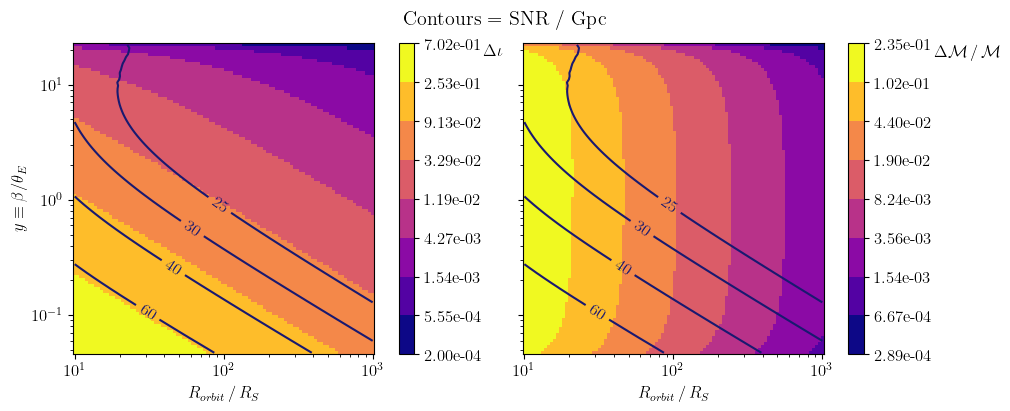

In [58]:
cmap = plt.get_cmap('plasma')
SNR_levels = [25, 30, 40, 60]

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey='row', constrained_layout=True)

ax = axs[0]
plot_discrete_colormesh(R_orbit_array, y_array, delta_iota,
                          fig, ax, cmap, n_levels=8, lognorm=True, 
                          cbar_label=r'$\Delta\iota$', labelpad=15)
ax.set_ylabel(r'$y\equiv\beta/\theta_E$')

ax = axs[1]
plot_discrete_colormesh(R_orbit_array, y_array, frac_mass_diff,
                          fig, ax, cmap, n_levels=8, lognorm=True,
                          cbar_label=r'$\Delta \mathcal M\,/\,\mathcal M$', labelpad=50)

# Hard-picked label locations for contour lines
nice_positions = [
    [30, 0.1],
    [40, 0.2],
    [70, 0.7],
    [100, 1]
]
for ax in axs:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$R_{orbit}\,/\,R_S$')
    contour = ax.contour(R_orbit_array, y_array, SNR_at_1_Gpc,
                          levels=SNR_levels, colors='midnightblue')
    ax.clabel(contour, fmt='%d', colors='midnightblue', manual=nice_positions)

fig.suptitle(r'Contours = SNR / Gpc')

In [ ]:
# Below is the code for continuous colorbar

# SNR_levels = [25, 30, 40, 60]

# fig, axs = plt.subplots(1, 2, figsize=(9, 4), sharey='row', constrained_layout=True)

# ax = axs[0]
# im = ax.pcolormesh(R_orbit_array, y_array, delta_iota,
#                        norm=LogNorm()
#                        )
# cbar = fig.colorbar(im)
# cbar.set_label(r'$\Delta\iota$', labelpad=-10, loc='top', rotation=0)
# contour = ax.contour(R_orbit_array, y_array, SNR_at_1_Gpc,
#                          levels=SNR_levels, colors='black')
# ax.clabel(contour, fmt='%1.1f', colors='black')
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_ylabel(r'$y\equiv\beta/\theta_E$')
# ax.set_xlabel(r'$R_{orbit}\,/\,R_S$')

# ax = axs[1]
# im = ax.pcolormesh(R_orbit_array, y_array, frac_mass_diff,
#                        norm=LogNorm()
#                        )
# cbar = fig.colorbar(im)
# cbar.set_label(r'$\Delta\mathcal{M}\,/\,\mathcal{M}$', labelpad=40, loc='top', rotation=0)
# contour = ax.contour(R_orbit_array, y_array, SNR_at_1_Gpc,
#                          levels=SNR_levels, colors='black')
# ax.clabel(contour, fmt='%1.1f', colors='black')
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_xlabel(r'$R_{orbit}\,/\,R_S$')

# fig.suptitle(r'Contours = SNR / Gpc')